In [8]:
from google.colab import files
uploaded = files.upload()

Saving Twitter Customer Services.xlsx to Twitter Customer Services.xlsx


In [9]:
# Cell 1: Environment Setup
!pip install -q transformers nltk spacy scikit-learn seaborn matplotlib pandas plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

print("Libraries successfully loaded.")

Libraries successfully loaded.


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [10]:
# Cell 2: Load Real Customer Service Data
import pandas as pd

# 1. Read the Excel file
df = pd.read_excel('Twitter Customer Services.xlsx')

# 2. Filter for incoming customer tweets (inbound = True)
df = df[df['inbound'] == True].copy()

# 3. Map the tweet text column to customer_text
df['customer_text'] = df['text']

# Display first few rows
print(f"Total Customer Tweets Loaded: {len(df)}")
df[['tweet_id', 'author_id', 'created_at', 'customer_text']].head()

Total Customer Tweets Loaded: 49


,tweet_id,author_id,created_at,customer_text
0,119237,105834,Wed Oct 11 06:55:44 +0000 2017,@AppleSupport causing the reply to be disregar...
2,119239,105835,Wed Oct 11 13:00:09 +0000 2017,@76328 I really hope you all change but I'm su...
4,119241,105836,Tue Oct 10 15:17:21 +0000 2017,@VirginTrains see attached error message. I've...
6,119244,105836,Tue Oct 10 15:26:44 +0000 2017,"@VirginTrains yep, I've tried laptop too sever..."
8,119242,105836,Tue Oct 10 15:09:00 +0000 2017,@VirginTrains I still haven't heard &amp; the ...


In [12]:
# Cell 3: Data Cleaning
def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

df['cleaned_text'] = df['customer_text'].apply(clean_text)
df[['customer_text', 'cleaned_text']].head()

,customer_text,cleaned_text
0,@AppleSupport causing the reply to be disregar...,applesupport causing the reply to be disregard...
2,@76328 I really hope you all change but I'm su...,i really hope you all change but im sure you w...
4,@VirginTrains see attached error message. I've...,virgintrains see attached error message ive tr...
6,"@VirginTrains yep, I've tried laptop too sever...",virgintrains yep ive tried laptop too several ...
8,@VirginTrains I still haven't heard &amp; the ...,virgintrains i still havent heard amp the numb...


In [13]:
# Cell 4: Sentiment Scoring
sid = SentimentIntensityAnalyzer()

df['compound_score'] = df['cleaned_text'].apply(lambda x: sid.polarity_scores(x)['compound'])

# Categorize sentiment into operational classes
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['predicted_sentiment'] = df['compound_score'].apply(categorize_sentiment)
df[['cleaned_text', 'compound_score', 'predicted_sentiment']]

,cleaned_text,compound_score,predicted_sentiment
0,applesupport causing the reply to be disregard...,-0.3818,Negative
2,i really hope you all change but im sure you w...,0.6183,Positive
4,virgintrains see attached error message ive tr...,-0.4019,Negative
6,virgintrains yep ive tried laptop too several ...,0.2960,Positive
8,virgintrains i still havent heard amp the numb...,-0.6124,Negative
11,applesupport me too am suffering hope the can ...,0.2732,Positive
12,applesupport hi apple ive a concern about the ...,0.1536,Positive
14,i just updated my phone and suddenly everythin...,-0.8750,Negative
16,spotifycares thanks version armv on anker blue...,0.4588,Positive
18,spotifycares no but ive moved speaker to about...,-0.1531,Negative


In [14]:
# Cell 5: Topic Extraction
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_mat = tfidf.fit_transform(df['cleaned_text'])

nmf_model = NMF(n_components=2, random_state=42)
nmf_model.fit(tfidf_mat)

feature_names = tfidf.get_feature_names_out()

for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-5:-1]]
    print(f"Topic {topic_idx + 1} Keywords: {', '.join(top_words)}")

Topic 1 Keywords: applesupport, phone, ios, update
Topic 2 Keywords: ive, tesco, tried, spotifycares


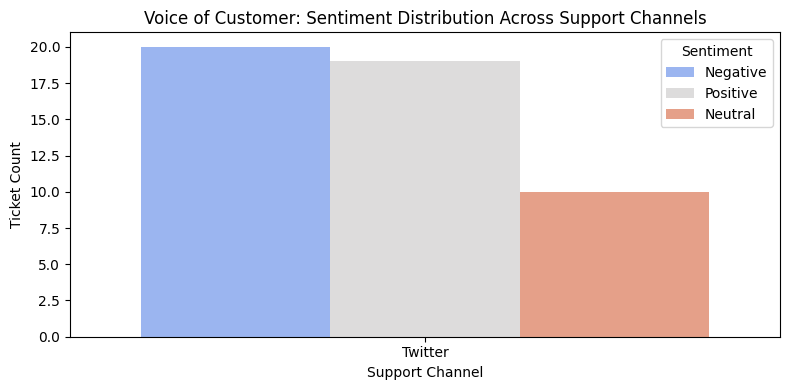

In [17]:
# Cell 6: Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Assign 'Twitter' as the channel for all tweets
df['channel'] = 'Twitter'

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='channel', hue='predicted_sentiment', palette='coolwarm')
plt.title('Voice of Customer: Sentiment Distribution Across Support Channels')
plt.xlabel('Support Channel')
plt.ylabel('Ticket Count')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()